(128681, 22)
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        

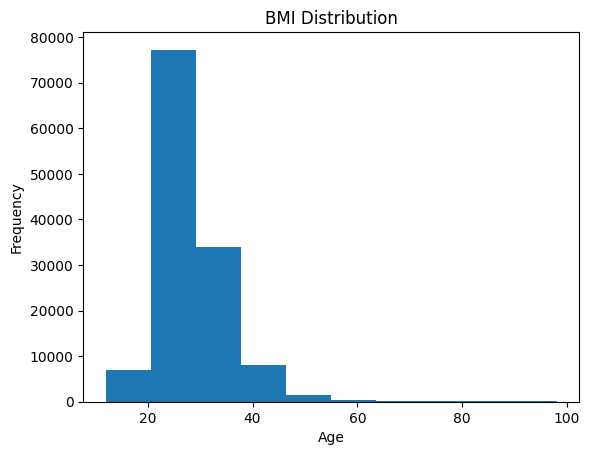

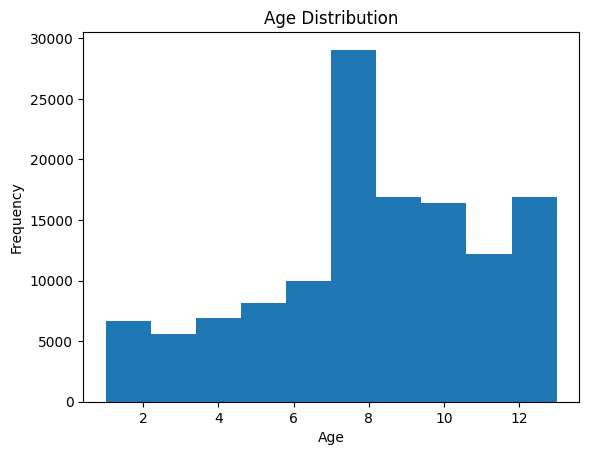

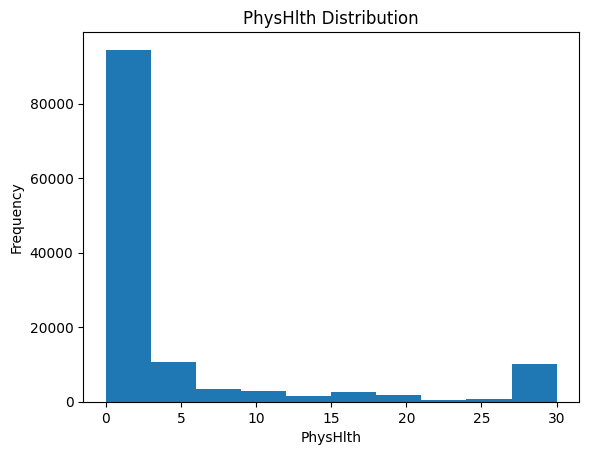

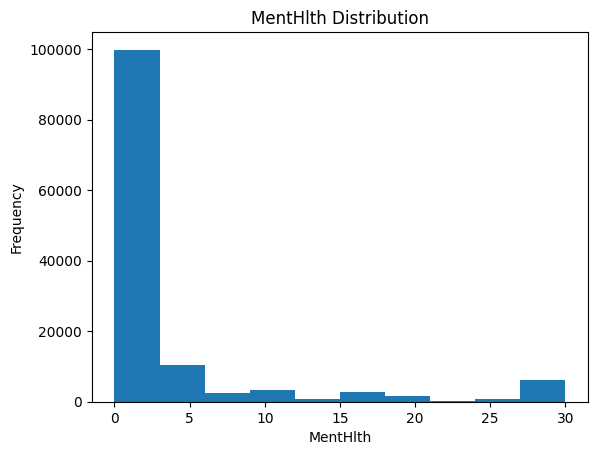

Before Remove duplicates :  (128681, 22)
After Remove duplicates :  (119672, 22)
columns_must_fix: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
missing values after fixing: 
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
   Diabet

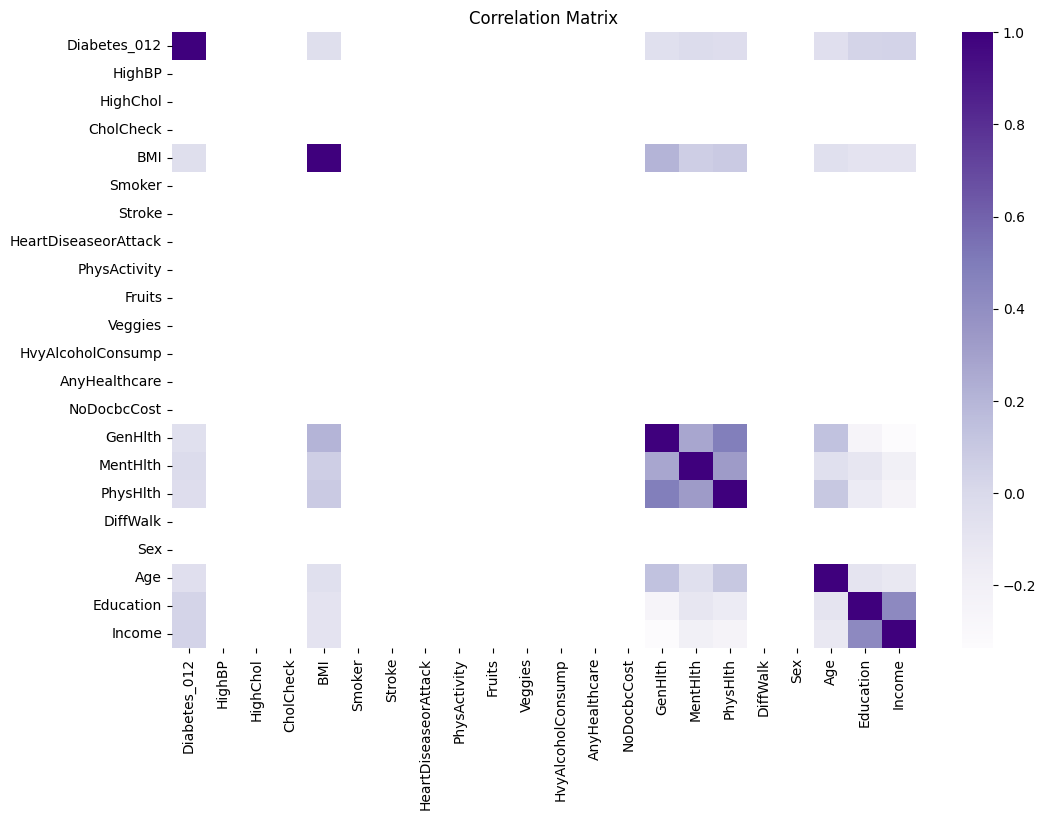

Train size: (95737, 10)
Test size: (23935, 10)
Class distribution before balancing: Counter({1.0: 93813, 0.0: 1924})
Class distribution after SMOTE: Counter({1.0: 93813, 0.0: 93813})


In [ ]:


import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

print(df.shape)
print(df.head())
print(df.columns)
df.info()
print(df.isnull().sum())
df.describe()

plt.hist(df['BMI'], bins=10)
plt.title('BMI Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.hist(df['Age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.hist(df['PhysHlth'], bins=10)
plt.title('PhysHlth Distribution')
plt.xlabel('PhysHlth')
plt.ylabel('Frequency')
plt.show()

plt.hist(df['MentHlth'], bins=10)
plt.title('MentHlth Distribution')
plt.xlabel('MentHlth')
plt.ylabel('Frequency')
plt.show()

print("Before Remove duplicates : ", df.shape)
df = df.drop_duplicates()
print("After Remove duplicates : ", df.shape)

columns_must_fix = df.select_dtypes(include=[np.number]).columns.tolist()
print("columns_must_fix:",columns_must_fix)
for  col in columns_must_fix:
  df[col]=df[col].replace(0,np.nan)
  df[col]=df[col].fillna(df[col].median())
print("missing values after fixing: ")
print(df[columns_must_fix].isnull().sum())

scaler=MinMaxScaler()
df[columns_must_fix]=scaler.fit_transform(df[columns_must_fix])
print(df[columns_must_fix].head())

categorical_cols= ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',

                    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',

                    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk',

                    'Sex', 'Education', 'Income', 'GenHlth']

encoder=LabelEncoder()
for col in categorical_cols:
  df[col]=encoder.fit_transform(df[col])
  print(df[categorical_cols].head())


from sklearn.feature_selection import SelectKBest, chi2

X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features)

import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="Purples", annot=False)
plt.title("Correlation Matrix")
plt.show()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

from imblearn.over_sampling import SMOTE
from collections import Counter

print("Class distribution before balancing:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:", Counter(y_train_bal))

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test = scaler.transform(X_test)




[Logistic Regression]
  - Accuracy  : 0.9464
  - Precision : 0.9609
  - Recall    : 0.9464

[Decision Tree]
  - Accuracy  : 0.7449
  - Precision : 0.9629
  - Recall    : 0.7449

[Random Forest]
  - Accuracy  : 0.9799
  - Precision : 0.9601
  - Recall    : 0.9799

[XGBoost]
  - Accuracy  : 0.9787
  - Precision : 0.9605
  - Recall    : 0.9787



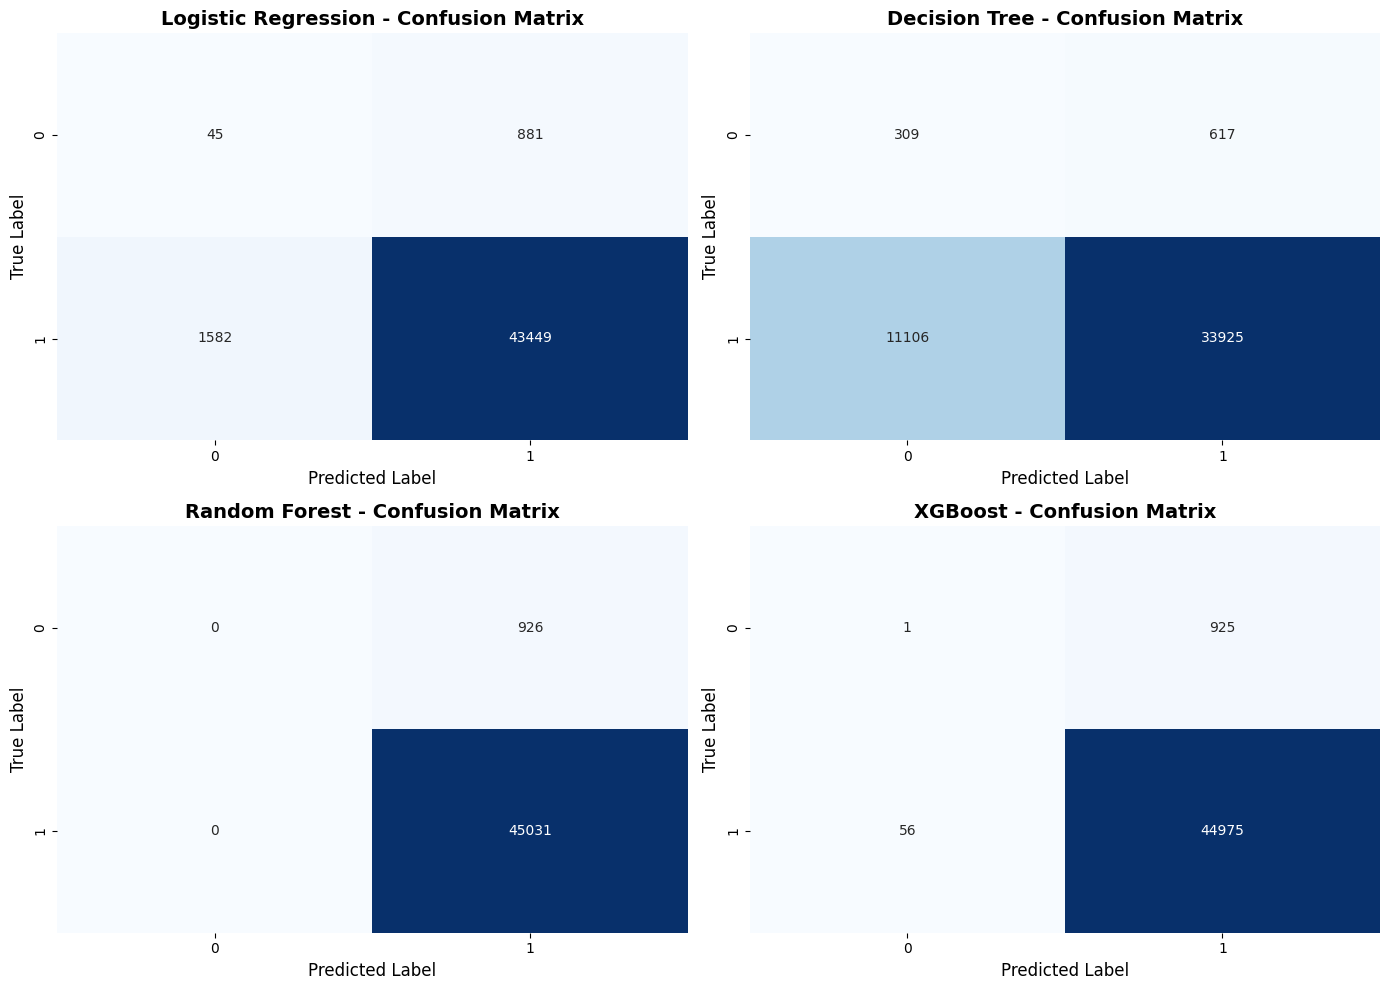

No ROC curves could be plotted for class 2 across any model because class 2 was either not predicted by the models or not present in the test set.


<Figure size 1000x800 with 0 Axes>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

predictions = {}
probabilities = {}





for name, model in models.items():

    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

    probabilities[name] = model.predict_proba(X_test)



for name, y_pred in predictions.items():

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')

    print(f"[{name}]")
    print(f"  - Accuracy  : {acc:.4f}")
    print(f"  - Precision : {prec:.4f}")
    print(f"  - Recall    : {rec:.4f}\n")


plt.figure(figsize=(14, 10))
for i, (name, y_pred) in enumerate(predictions.items(), 1):
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


y_test_diabetes_binary = (y_test == 2).astype(int)

plt.figure(figsize=(10, 8))
roc_plotted = False

for name, prob in probabilities.items():
    model_classes = models[name].classes_

    if 2.0 in model_classes:
        class_2_index = list(model_classes).index(2.0)

        if np.sum(y_test_diabetes_binary) > 0:
            y_prob_diabetes = prob[:, class_2_index]

            fpr, tpr, thresholds = roc_curve(y_test_diabetes_binary, y_prob_diabetes)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
            roc_plotted = True
        else:
            print(f"Warning: Class 2 (Diabetes) is predicted by {name} but no samples of class 2 found in y_test. Skipping ROC for class 2.")
    else:
        print(f"Warning: Class 2 (Diabetes) not found in {name}'s predicted classes ({model_classes}). Skipping ROC for class 2.")

# Only show the plot if at least one ROC curve was successfully plotted
if roc_plotted:
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve (Detecting Diabetes - Class 2)', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No ROC curves could be plotted for class 2 across any model because class 2 was either not predicted by the models or not present in the test set.")